## Recipe to evaluate model SSH with satellite image product 



**This recipe will show a model agnostic example onto how to evaluate the model SSH over a satellite data. In this example, the satellite product chosen is from [Copernicus](https://data.marine.copernicus.eu/product/SEALEVEL_GLO_PHY_L4_MY_008_047/description), and the models chosen are ROMS and MOM6**


Steps:
- Read model and satellite data
- Interpolate the higher-resolution data to the coarser to get the same points and same area
- Calculate the time-mean
- Check the differences
- Calculate the seasonality and compare
- Calculate RMSE


In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
from dask.distributed import Client
client = Client(threads_per_worker = 1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46769,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38169,Total threads: 1
Dashboard: /proxy/36271/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:45849,


In [2]:
#Model specific information.
#note that we are currently calling coordinates (lat_var, lon_var etc) in each step using this notation: lon_var= model_args[model]['lon_var']
#we could simplify by using cf_xarray https://cf-xarray.readthedocs.io/en/latest/index.html
model_args = {
              "roms": {"data_var": "zeta",
                       "lat_var": "lat_rho",
                       "lon_var": "lon_rho",
                       "time_var": 'ocean_time',
                       #z_var and z_inx needed for 3d data. leave these as unset if data is already 2D, surface-only
                       "z_var": "s_rho",
                       "z_inx": -1,
                       "file_name":'/g/data/yj27/users/cgk561/30yr_run_1993_2023_CK/output/roms_his_08[34567]*',

             },
              "mom6": { "data_var": "zos",
                       "lat_var": "yh",
                       "lon_var": "xh",
                       'time_var': 'time',
                       "file_name": "/g/data/av17/access-nri/rOM3/superaus/v20260619/expt08_outputs3/output*/access-om3.mom6.2d.zos.1day.mean*.nc",
 
              }
}

In [3]:
#Spefifying the region and models we want to investigate:
lon_min = 145
lon_max = 165
lat_min = -42
lat_max = -24
models = ['roms', 'mom6']

In [4]:
# Reading the data. 
ssh = {}
for model in models:
    varname = model_args[model]['data_var']
    files = model_args[model]['file_name']
    time_var = model_args[model]['time_var']
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    time_var = model_args[model]['time_var']
    ssh[model] = xr.open_mfdataset(files, parallel=True, decode_timedelta=True,chunks={time_var: 1, lat_var: 'auto', lon_var: 'auto'} )[varname]
    ssh[model] = ssh[model].drop_duplicates(time_var, keep='first')


copernicus_all = xr.open_mfdataset('/g/data/yj27/data/obs/aviso/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_*').sla




/jobfs/172460486.gadi-pbs/ipykernel_1883897/1534277643.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ssh[model] = xr.open_mfdataset(files, parallel=True, decode_timedelta=True,chunks={time_var: 1, lat_var: 'auto', lon_var: 'auto'} )[varname]
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/_task_spec.py:767: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return self.func(*new_argspec, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/sit

In [5]:
# Selecting the same time for roms, mom and ostia - said to be occuring at the same time if only 12 hours apart (method='nearest',tolerance='12h')

#subsetting OSTIA recurssivly by subsetting time matches with each model indiviually
for model in models:
    time_var = model_args[model]['time_var']
    copernicus = copernicus_all.reindex(time=ssh[model][time_var].values, method='nearest',tolerance='12h').dropna(dim='time', how='all')
    copernicus = copernicus.drop_duplicates('time', keep='first')
#The subsetted ostia times will now be the overlap between all models and ostia     
target_times = copernicus.time.values

for model in models:
    time_var = model_args[model]['time_var']
    ssh[model] = ssh[model].reindex({time_var: target_times}, method='nearest',tolerance='12h')





In [6]:
#Subsettng by lat and lon 
for model in models:
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    mask = ( (ssh[model][lat_var] < lat_max) & (ssh[model][lat_var] > lat_min)  & (ssh[model][lon_var] >lon_min) &  (ssh[model][lon_var]<lon_max)).compute()
    ssh[model] = ssh[model].where(mask, drop=True)

mask = ( (copernicus.latitude < lat_max) & (copernicus.latitude > lat_min)  & (copernicus.longitude >lon_min) &  (copernicus.longitude<lon_max) ).compute()
copernicus = copernicus.where(mask, drop=True)

In [7]:
# removing mean SSH
copernicus = copernicus - copernicus.mean()
for model in models:
    ssh[model] = ssh[model] - ssh[model].mean()

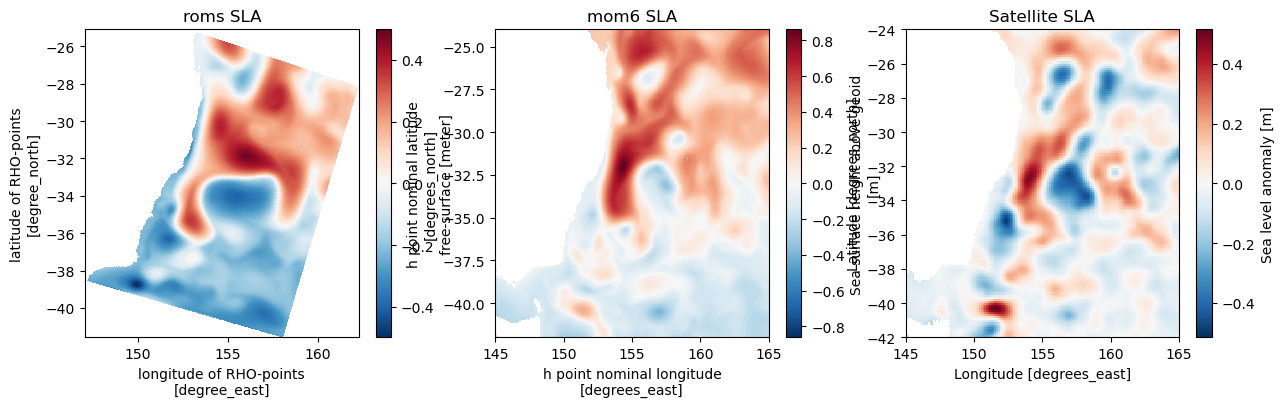

In [8]:
# Checking one day for our SSH data

ncols = len(model_args) +1
fig, ax = plt.subplots(ncols=ncols, figsize=(ncols*5, 4))
n = 0
for model in models:
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    time_var = model_args[model]['time_var']
    ssh[model].isel({time_var:0}).plot(ax=ax[n], x=lon_var, y=lat_var)
    ax[n].set_title(model + ' SLA')
    n = n+1
    
copernicus.isel(time=0).plot(ax=ax[n], x='longitude', y='latitude')
ax[n].set_title('Satellite SLA');



In [9]:
# Checking grid resolution (OSTIA is 0.05° and ROMS is variable from 0.02 to 0.06)

for model in models:
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    leng = len(ssh[model][lat_var].sizes)
    if leng <2.0:
        print(model, '  grid resolution:', ssh[model][lon_var][1] - ssh[model][lon_var][0], ssh[model][lat_var][1] - ssh[model][lat_var][0])
        print("creating 2d lat / lon for", model)
        LON, LAT = np.meshgrid(ssh[model][lon_var].values, ssh[model][lat_var].values)
        ssh[model] = ssh[model].assign_coords(y2d=(("yh", "xh"), LAT))
        ssh[model] = ssh[model].assign_coords(x2d=(("yh", "xh"), LON))
        model_args[model]['lat_var'] = 'y2d'
        model_args[model]['lon_var'] = 'x2d'
    else: 
        print(model, ' grid resolution:', ssh[model][lon_var][0, 1] - ssh[model][lon_var][0, 0], ssh[model][lat_var][1, 0] - ssh[model][lat_var][0, 0])



roms  grid resolution: <xarray.DataArray 'lon_rho' ()> Size: 8B
array(0.03247193)
Attributes:
    standard_name:  grid_longitude_at_cell_center
    long_name:      longitude of RHO-points
    units:          degree_east
    field:          lon_rho <xarray.DataArray 'lat_rho' ()> Size: 8B
array(0.04234901)
Attributes:
    standard_name:  grid_latitude_at_cell_center
    long_name:      latitude of RHO-points
    units:          degree_north
    field:          lat_rho
mom6   grid resolution: <xarray.DataArray 'xh' ()> Size: 8B
array(0.03333333)
Attributes:
    units:      degrees_east
    long_name:  h point nominal longitude
    axis:       X <xarray.DataArray 'yh' ()> Size: 8B
array(0.02995868)
Attributes:
    units:      degrees_north
    long_name:  h point nominal latitude
    axis:       Y
creating 2d lat / lon for mom6


In [10]:
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator
# Interpolate model grid to OSTIA grid (higher resolution into coarser resolution)
LON, LAT = np.meshgrid(copernicus.longitude, copernicus.latitude)
ssh_regrided = {}
# Flatten the arrays for interpolation
for model in models:
    print('Starting for model ', model)
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    time_var = model_args[model]['time_var']
    points = np.array([ssh[model][lon_var].values.ravel(), ssh[model][lat_var].values.ravel()]).T
    regridded_list = []
    #Calculating interpolation weights in advance to speed this up. 
    print("Building source triangulation grid...")
    triangulation = Delaunay(points) 
    target_coords = np.column_stack((LON.ravel(), LAT.ravel()))
    for TT in ssh[model][time_var].values:
        print(TT)
        # Extract values for the current time step
        values = ssh[model].sel({time_var: TT}).values.ravel()
        # Interpolate onto OSTIA grid
        fast_interpolator = LinearNDInterpolator(triangulation, values, fill_value=np.nan)
        interpolated_flat = fast_interpolator(target_coords)
        interpolated = interpolated_flat.reshape(LON.shape)
        # Convert interpolated result to a DataArray with correct dimensions
        interpolated_da = xr.DataArray(
        interpolated,
        dims=("latitude", "longitude"),
        coords={"latitude": copernicus.latitude, "longitude": copernicus.longitude, "time": TT},
        )
        # Append to list
        regridded_list.append(interpolated_da)

    # Concatenate along time dimension
    ssh_regrided[model] = xr.concat(regridded_list, dim="time")

Starting for model  roms
Building source triangulation grid...
2013-01-01T12:00:00.000000000
2013-01-02T12:00:00.000000000
2013-01-03T12:00:00.000000000
2013-01-04T12:00:00.000000000
2013-01-05T12:00:00.000000000
2013-01-06T12:00:00.000000000
2013-01-07T12:00:00.000000000
2013-01-08T12:00:00.000000000
2013-01-09T12:00:00.000000000
2013-01-10T12:00:00.000000000
2013-01-11T12:00:00.000000000
2013-01-12T12:00:00.000000000
2013-01-13T12:00:00.000000000
2013-01-14T12:00:00.000000000
2013-01-15T12:00:00.000000000
2013-01-16T12:00:00.000000000
2013-01-17T12:00:00.000000000
2013-01-18T12:00:00.000000000
2013-01-19T12:00:00.000000000
2013-01-20T12:00:00.000000000
2013-01-21T12:00:00.000000000
2013-01-22T12:00:00.000000000
2013-01-23T12:00:00.000000000
2013-01-24T12:00:00.000000000
2013-01-25T12:00:00.000000000
2013-01-26T12:00:00.000000000
2013-01-27T12:00:00.000000000
2013-01-28T12:00:00.000000000
2013-01-29T12:00:00.000000000
2013-01-30T12:00:00.000000000
2013-01-31T12:00:00.000000000
2013-02

In [12]:
# Let's mask satellite data to match only the part of the roms data.
# Doing for roms as well, to remove the big nan area created by the interpolation.
ssh_masked = {}
for model in models:
    sat_masked = copernicus.where(~np.isnan(ssh_regrided[model]), drop=True)
    copernicus = sat_masked


for model in models:
    tmp1 = ssh_regrided[model].compute()
    tmp2 = ~np.isnan(sat_masked).compute()
    ssh_masked[model] = tmp1.where(tmp2, drop=True)

    
#sat_masked = copernicus.where(~np.isnan(roms_regrided), drop=True)
#roms_masked = roms_regrided.where(~np.isnan(roms_regrided), drop=True)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 10.94 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 10.94 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [13]:
# Calculating the RMS and STD
ssh_rms = {}
ssh_std = {}
for model in models:
    ssh_rms[model] = np.sqrt((ssh_masked[model]**2).mean('time'))
    ssh_std[model] = ssh_masked[model].std('time')

sat_rms = np.sqrt((sat_masked**2).mean('time'))
sat_std = sat_masked.std('time')

In [14]:
# Calculating the difference from the time-mean
sshdiff = {}
for model in models:
    sshdiff[model] = sat_rms - ssh_rms[model]

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 10.94 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 11.06 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.d

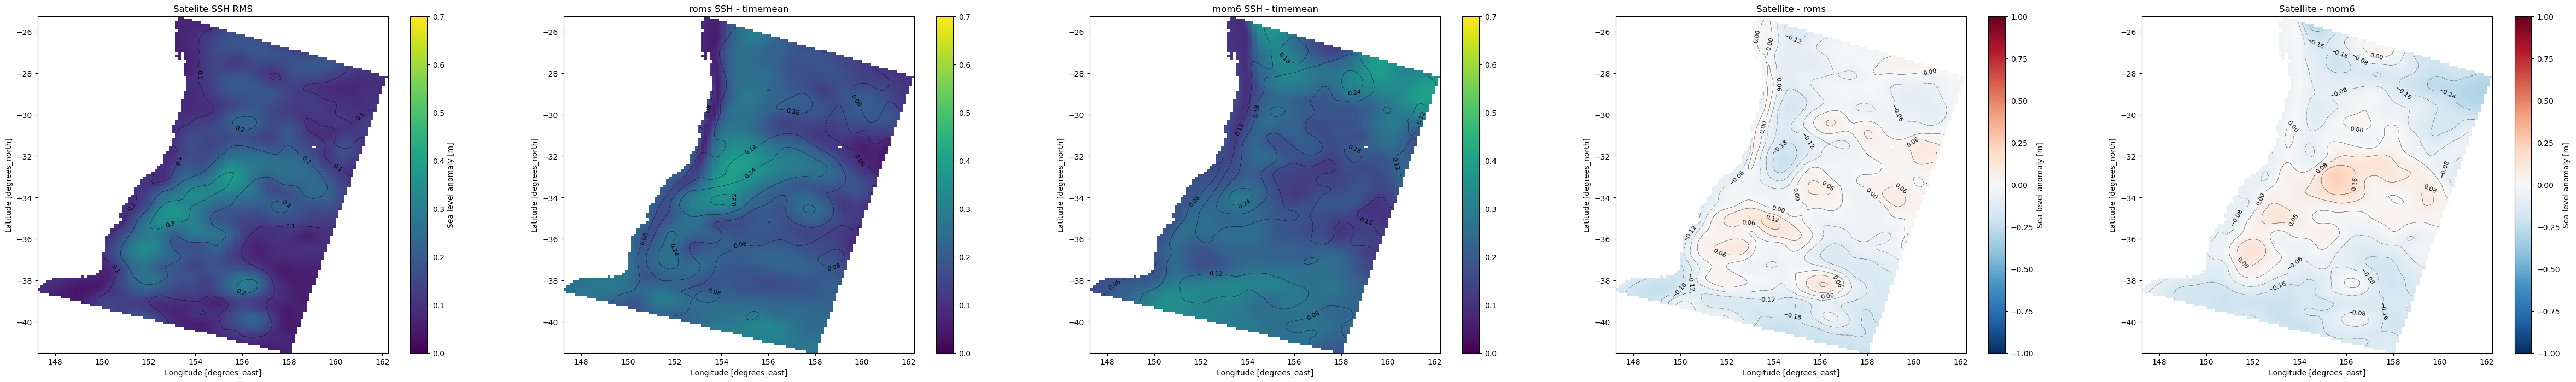

In [15]:
# Checking the timemean comparison

nomodels = len(models)
ncols=2*nomodels +1
fig, ax = plt.subplots(ncols=ncols, figsize=(12*ncols, 8))

n = 0 #column number
sat_rms.plot(ax=ax[n], vmin=0, vmax=0.7)
cnt = sat_std.plot.contour(ax=ax[n], levels=5, colors=['k'], linewidths=0.3)
plt.clabel(cnt, inline=True, fontsize=8)
ax[n].set_title('Satelite SSH RMS');
n = n+1

for model in models:
    ssh_rms[model].plot(ax=ax[n], vmin=0, vmax=0.7)
    cnt = ssh_std[model].plot.contour(ax=ax[n], levels=5, colors=['k'], linewidths=0.3)
    plt.clabel(cnt, inline=True, fontsize=8)
    ax[n].set_title(model + ' SSH - timemean')
    n = n+1
    
for model in models:
    sshdiff[model].plot(ax=ax[n], vmin=-1, vmax=1, cmap='RdBu_r')
    cnt = sshdiff[model].plot.contour(ax=ax[n], levels=10, colors=['k'], linewidths=0.3)
    plt.clabel(cnt, inline=True, fontsize=8)
    ax[n].set_title('Satellite - ' + model);
    n = n+1


<br>

### **Doing the seasonal analysis**

In [16]:
# Grouping the data in seasons
model_seasons = {}
for model in models:
    model_seasons[model] = ssh_masked[model].groupby('time.season')

sat_seasons = sat_masked.groupby('time.season')

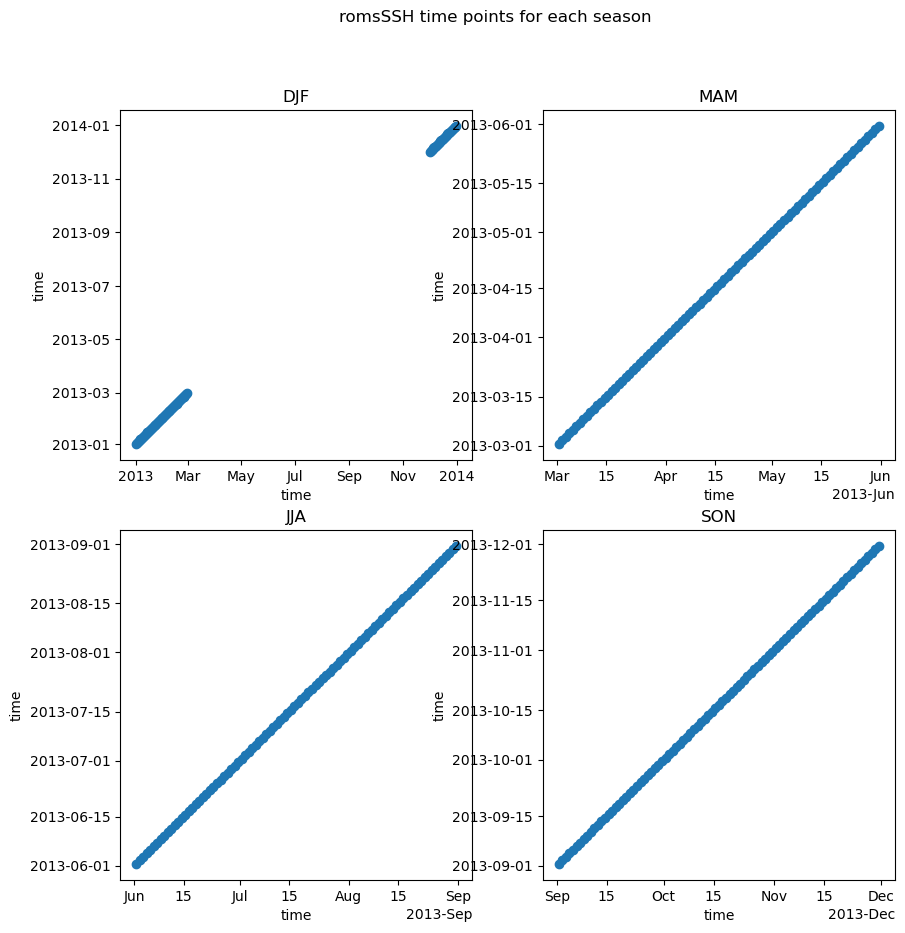

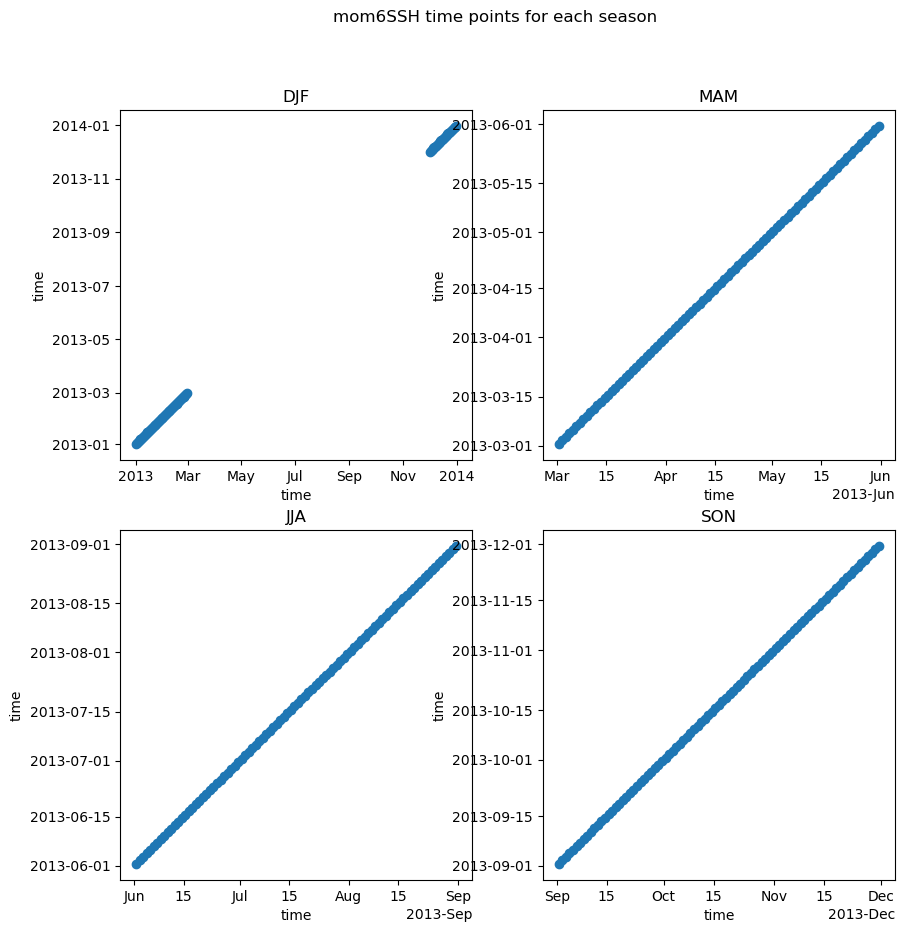

In [17]:
# Plotting the time points for DJF season without connecting the markers


for model in models:
    fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))
    model_seasons[model]['DJF'].time.plot(ax=ax[0, 0], marker='o', linestyle='None'); ax[0, 0].set_title('DJF')
    model_seasons[model]['MAM'].time.plot(ax=ax[0, 1], marker='o', linestyle='None'); ax[0, 1].set_title('MAM')
    model_seasons[model]['JJA'].time.plot(ax=ax[1, 0], marker='o', linestyle='None'); ax[1, 0].set_title('JJA')
    model_seasons[model]['SON'].time.plot(ax=ax[1, 1], marker='o', linestyle='None'); ax[1, 1].set_title('SON');
    fig.suptitle(model +  'SSH time points for each season');

In [18]:
# Now we know the our seasonal data is correct, let's calculate the seasonal rms and STD
sat_seasons_rms = sat_seasons.map(lambda x: np.sqrt((x**2).mean('time')))
sat_seasons_std = sat_seasons.std('time')

model_seasons_rms = {}
model_seasons_std = {}
for model in models:
    model_seasons_rms[model] = model_seasons[model].map(lambda x: np.sqrt((x**2).mean('time')))
    model_seasons_std[model] = model_seasons[model].std('time')


    

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 10.95 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 11.07 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/cli

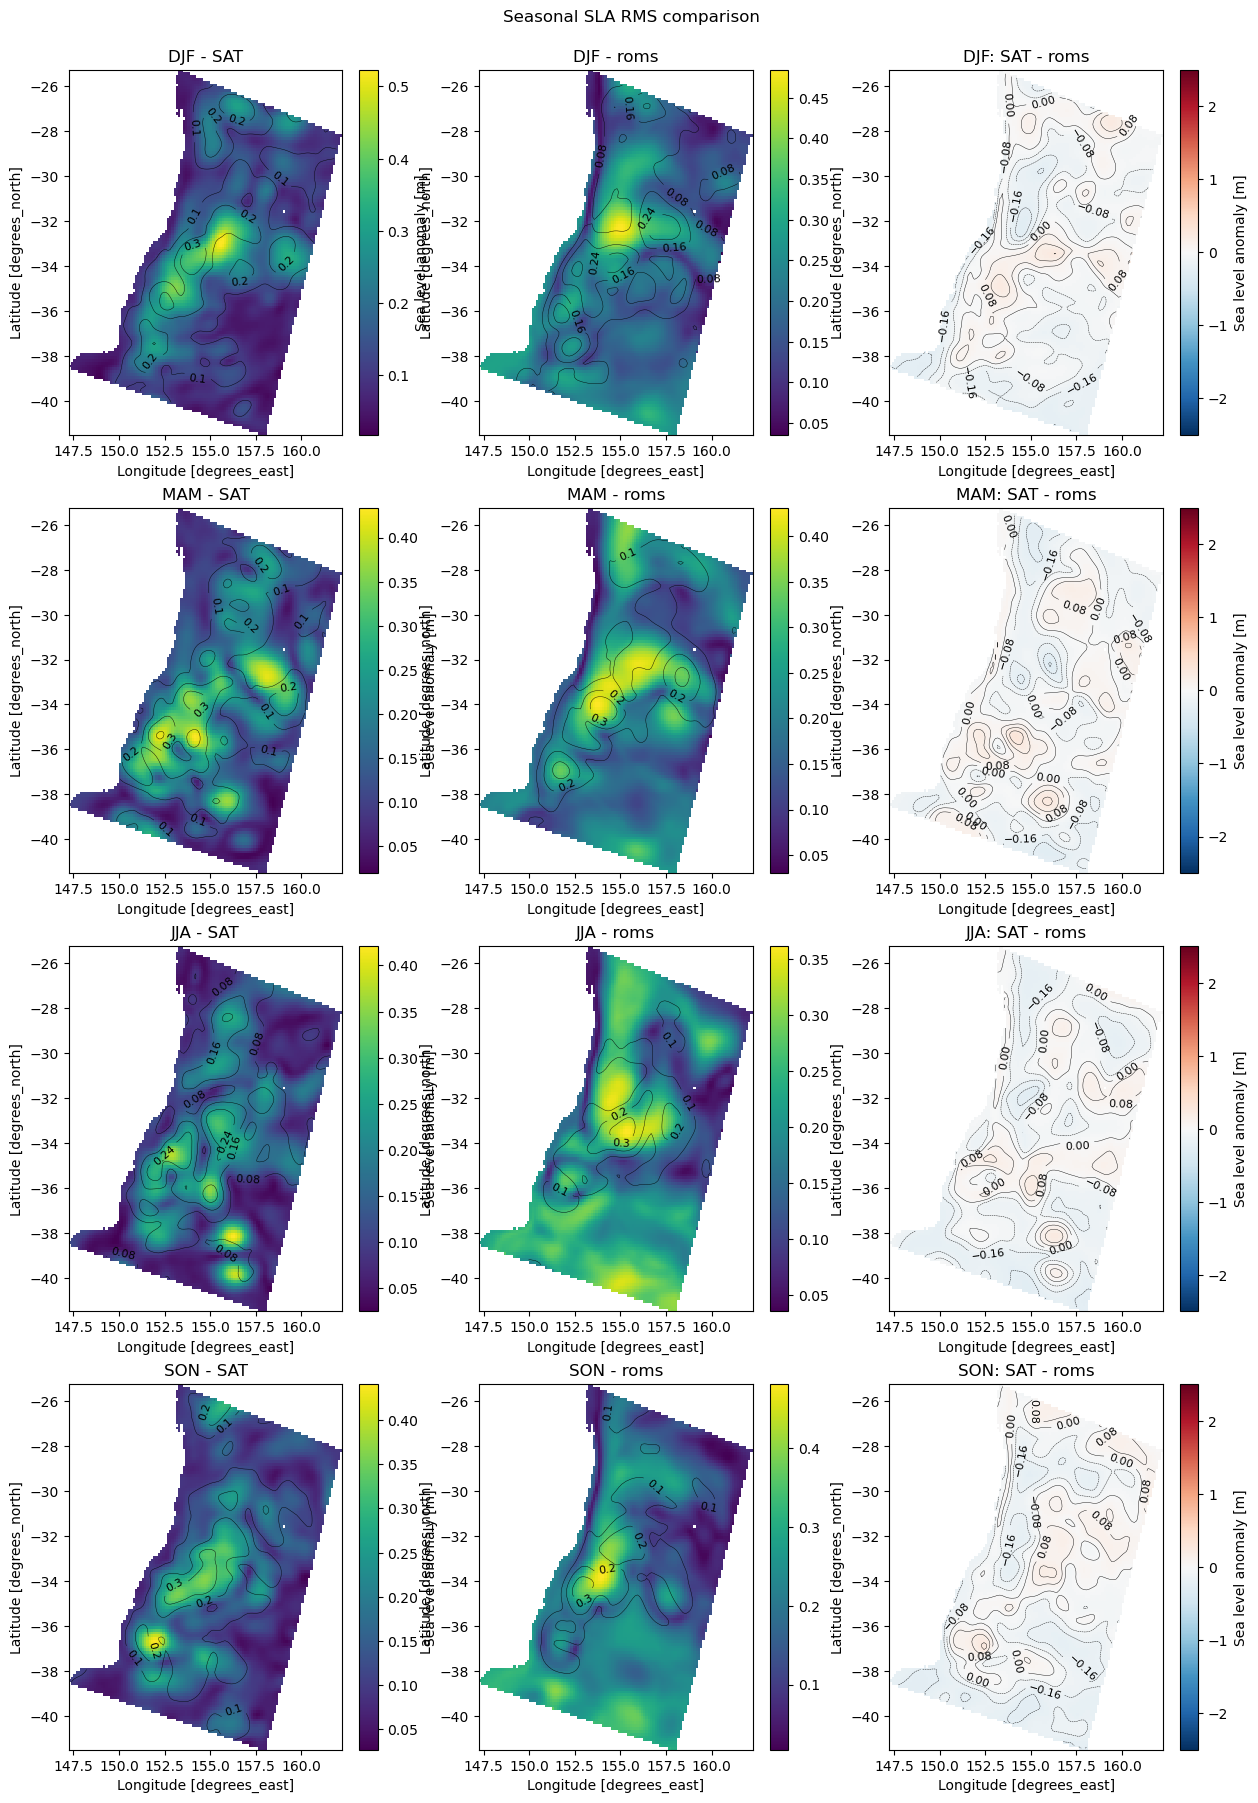

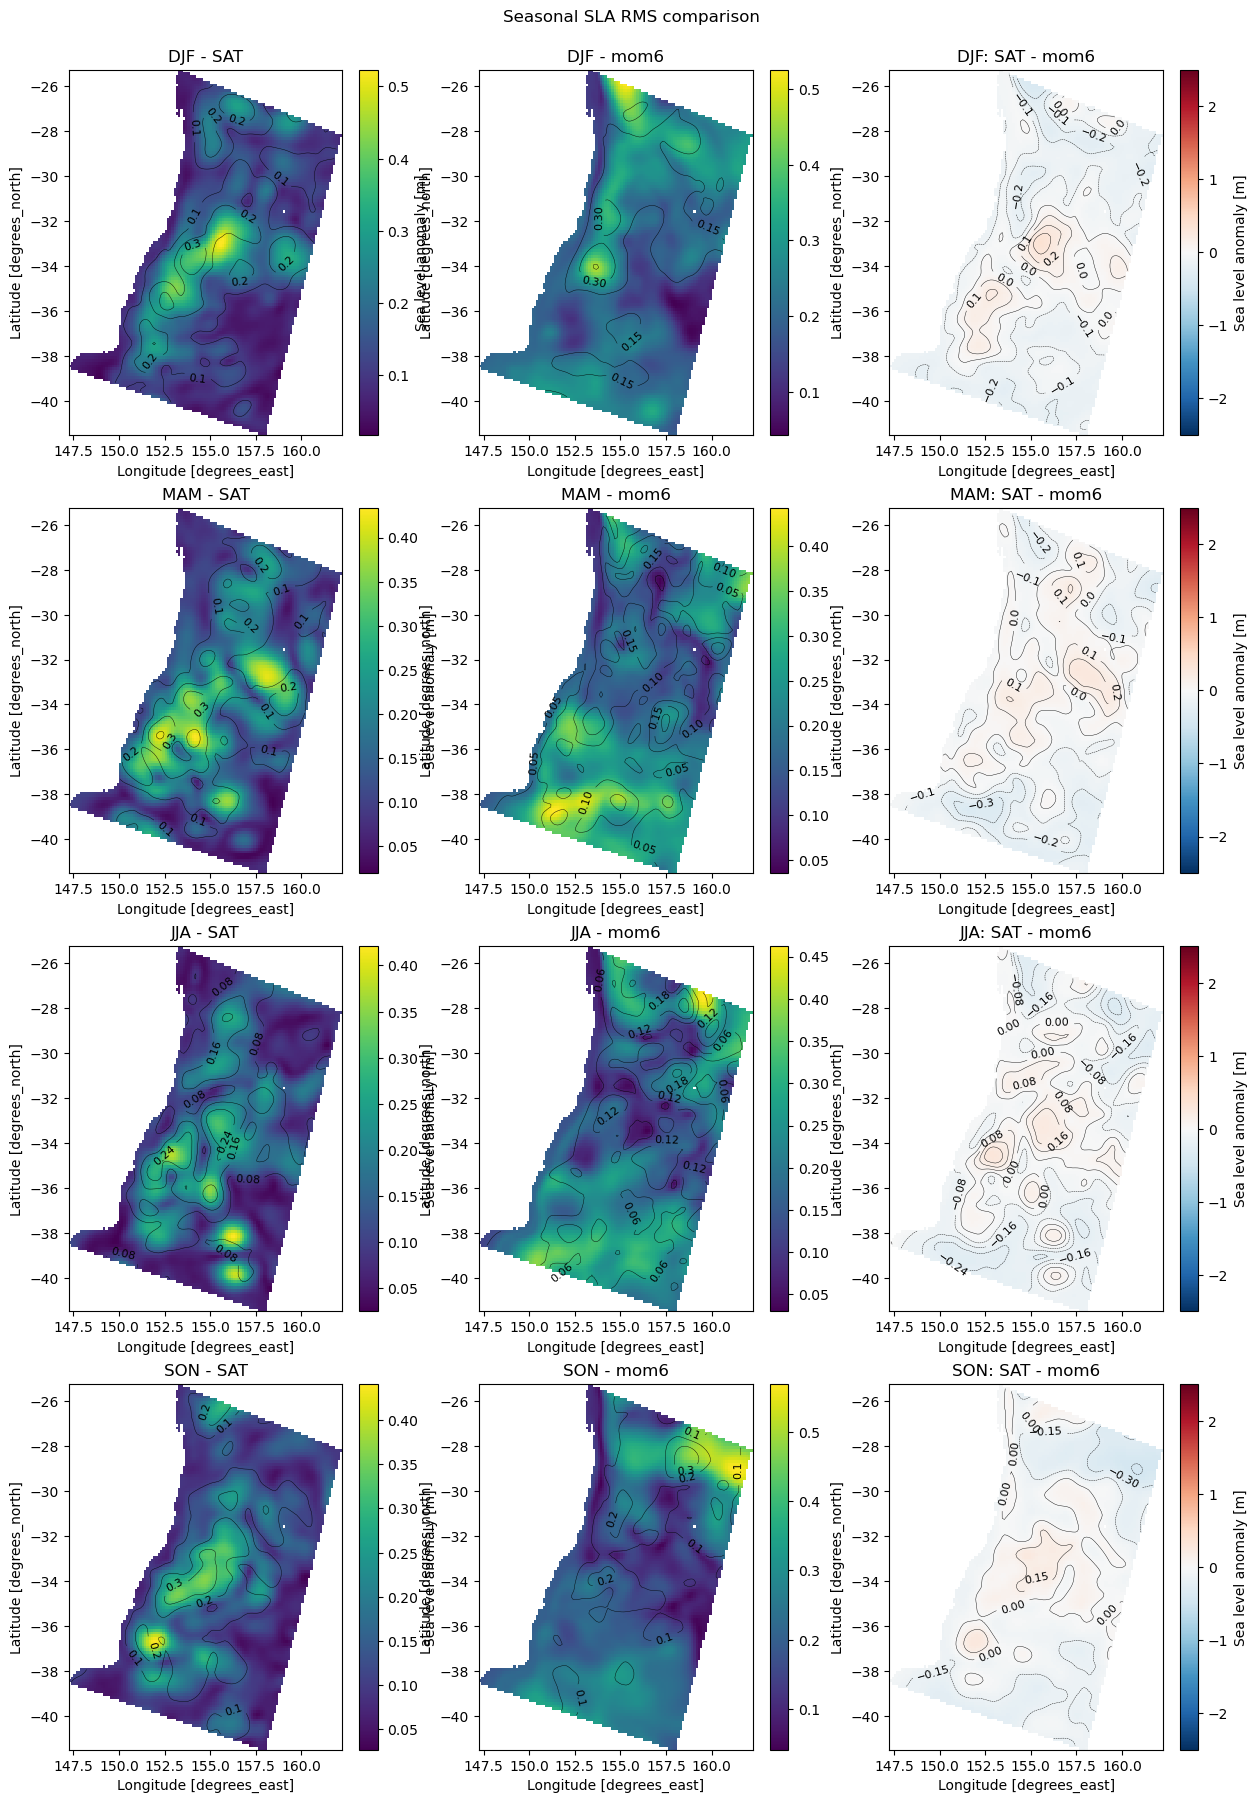

In [19]:
# Plotting each seasonal mean and calculating the difference between Satellite and ROMS

for model in models:
    fig, ax = plt.subplots(ncols=3, nrows=4, figsize=(15, 20))
    for enu, SS in enumerate(['DJF', 'MAM', 'JJA', 'SON']):
        # OSTIA
        sat_seasons_rms.sel(season=SS).plot(ax=ax[enu, 0])
        cnt = sat_seasons_std.sel(season=SS).plot.contour(ax=ax[enu, 0], levels=5, colors=['k'], linewidths=0.3)
        plt.clabel(cnt, inline=True, fontsize=8)
        # model
        model_seasons_rms[model].sel(season=SS).plot(ax=ax[enu, 1])
        cnt = model_seasons_std[model].sel(season=SS).plot.contour(ax=ax[enu, 1], levels=5, colors=['k'], linewidths=0.3)
        plt.clabel(cnt, inline=True, fontsize=8)
        
        # Calculating the difference
        diff = sat_seasons_rms.sel(season=SS) - model_seasons_rms[model].sel(season=SS)
        diff.plot(ax=ax[enu, 2], vmin=-2.5, vmax=2.5, cmap='RdBu_r')
        cnt = diff.plot.contour(ax=ax[enu, 2], levels=10, colors=['k'], linewidths=0.3)
        plt.clabel(cnt, inline=True, fontsize=8)
        
        # Adding titles
        ax[enu, 0].set_title(SS + ' - SAT')
        ax[enu, 1].set_title(SS + ' - ' + model)
        ax[enu, 2].set_title(SS + ': SAT - ' + model)
    fig.suptitle('Seasonal SLA RMS comparison');
    fig.subplots_adjust(top=0.95)

In [20]:
# Also, we can also calculate a spatial mean and plot the timeseries together
sat_spatial_mean = np.sqrt((sat_masked**2).mean(['latitude', 'longitude']))
model_spatial_mean = {}
rmse_model = {}
for model in models:
    model_spatial_mean[model] = np.sqrt((ssh_masked[model]**2).mean(['latitude', 'longitude']))
    #Calculating the RMSE for the spatial mean
    rmse_model[model] = ((sat_spatial_mean - ssh_masked[model])**2).mean() ** 0.5

    


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 10.94 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 54.39 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


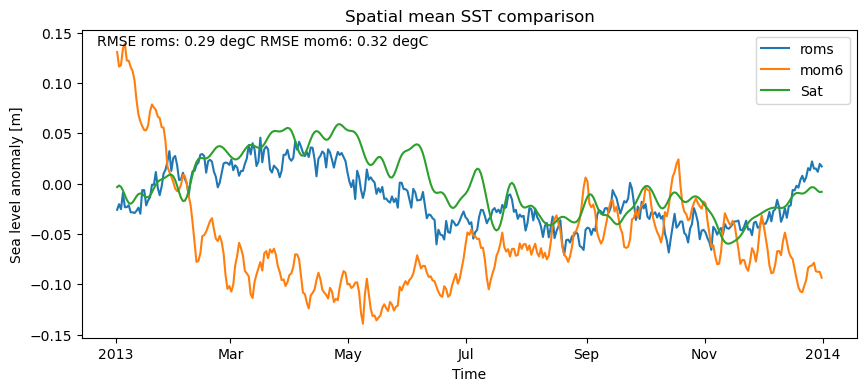

In [31]:
# Plotting the time series
fig, ax = plt.subplots(figsize=(10, 4))
for model in models:
    ssh_masked[model].mean(['latitude', 'longitude']).plot(ax=ax, label=model)
sat_masked.mean(['latitude', 'longitude']).plot(ax=ax, label='Sat')
ax.legend()

annotate_str = ''
for model in models:
    annotate_str = annotate_str + 'RMSE ' + model + ': {:.2f} degC '.format(rmse_model[model].values) 
annotate_str
ax.annotate(annotate_str, xy=(0.02, 0.95), xycoords='axes fraction')
ax.set_title('Spatial mean SST comparison');
